# Project 3: Unsupervised Learning - Customer Segmentation


## 1. Import Libraries and Load Data


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned dataset from Project 1
df = pd.read_csv('project_1_cleaned_dataset.csv')

print('Dataset shape:', df.shape)
print('\nFirst few rows:')
df.head()

print('\nColumn names:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

Dataset shape: (1200, 26)

First few rows:

Column names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'order_year', 'order_month', 'order_dayofweek', 'discount_flag', 'price_per_item', 'cart_fill_ratio', 'is_high_value_order', 'referral_feature', 'Quantity_is_outlier', 'UnitPrice_is_outlier', 'ItemsInCart_is_outlier', 'TotalPrice_is_outlier']

Data types:
OrderID                       str
Date                          str
CustomerID                    str
Product                       str
Quantity                  float64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart               float64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
order_year

## 2. Feature Selection and Scaling


In [2]:
# Select numeric features for clustering (exclude identifiers and categorical features)
exclude_cols = ['OrderID', 'Date', 'CustomerID', 'Product', 'ShippingAddress', 
                'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ReferralSource', 'CouponCode']

feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f'Total features: {len(feature_cols)}')
print('\nFeatures for clustering:')
print(feature_cols)

X = df[feature_cols].copy()

# Check for missing values
print('\nMissing values:')
print(X.isnull().sum())

# Handle any remaining missing values
X = X.fillna(X.mean())

# Standardize the features (PCA requires scaled data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nScaled feature matrix shape: {X_scaled.shape}')
print('Features standardized successfully')

Total features: 16

Features for clustering:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'order_year', 'order_month', 'order_dayofweek', 'discount_flag', 'price_per_item', 'cart_fill_ratio', 'is_high_value_order', 'referral_feature', 'Quantity_is_outlier', 'UnitPrice_is_outlier', 'ItemsInCart_is_outlier', 'TotalPrice_is_outlier']

Missing values:
Quantity                  0
UnitPrice                 0
ItemsInCart               0
TotalPrice                0
order_year                0
order_month               0
order_dayofweek           0
discount_flag             0
price_per_item            0
cart_fill_ratio           0
is_high_value_order       0
referral_feature          0
Quantity_is_outlier       0
UnitPrice_is_outlier      0
ItemsInCart_is_outlier    0
TotalPrice_is_outlier     0
dtype: int64

Scaled feature matrix shape: (1200, 16)
Features standardized successfully


## 3. Principal Component Analysis (PCA)


Explained Variance by Component:
  PC1: 0.2722 (27.22%)
  PC2: 0.1364 (13.64%)
  PC3: 0.1040 (10.40%)

Cumulative Variance Explained by 3 components: 0.5126 (51.26%)


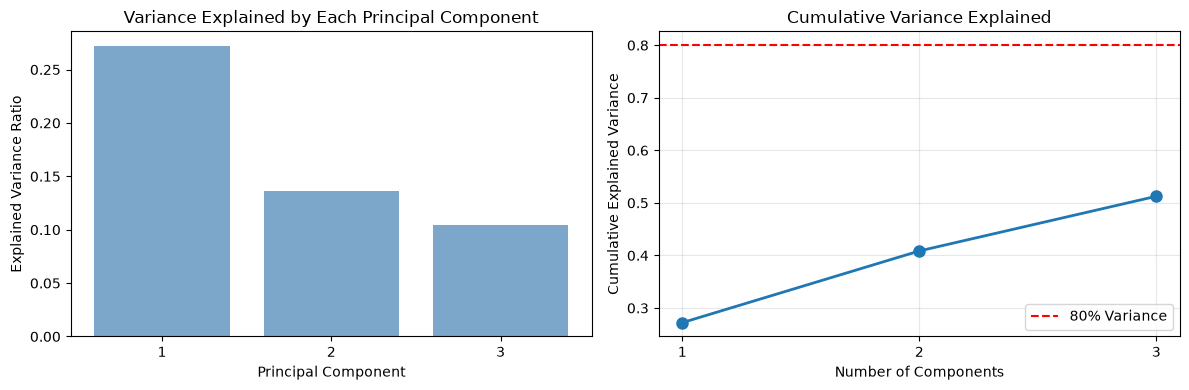


PCA reduced 16 features to 3 components
PCA component matrix shape: (1200, 3)


In [3]:
# Apply PCA to reduce to 3 dimensions
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Analyze explained variance
explained_var_ratio = pca.explained_variance_ratio_
cumulative_var_ratio = np.cumsum(explained_var_ratio)

print('Explained Variance by Component:')
for i, var in enumerate(explained_var_ratio):
    print(f'  PC{i+1}: {var:.4f} ({var*100:.2f}%)')

print(f'\nCumulative Variance Explained by 3 components: {cumulative_var_ratio[-1]:.4f} ({cumulative_var_ratio[-1]*100:.2f}%)')

# Visualize explained variance
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(range(1, 4), explained_var_ratio, alpha=0.7, color='steelblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance Explained by Each Principal Component')
plt.xticks([1, 2, 3])

plt.subplot(1, 2, 2)
plt.plot(range(1, 4), cumulative_var_ratio, 'o-', linewidth=2, markersize=8)
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks([1, 2, 3])

plt.tight_layout()
plt.show()

print(f'\nPCA reduced {X_scaled.shape[1]} features to {X_pca.shape[1]} components')
print(f'PCA component matrix shape: {X_pca.shape}')

## 4. Elbow Method - Optimal K Selection


K=2: Inertia=4772.68, Silhouette Score=0.3688
K=3: Inertia=3723.49, Silhouette Score=0.3242
K=4: Inertia=3148.84, Silhouette Score=0.3232
K=5: Inertia=2638.76, Silhouette Score=0.2920
K=6: Inertia=2238.11, Silhouette Score=0.3053
K=7: Inertia=1933.73, Silhouette Score=0.3086
K=8: Inertia=1712.53, Silhouette Score=0.3107
K=9: Inertia=1529.12, Silhouette Score=0.3159
K=10: Inertia=1409.80, Silhouette Score=0.3205


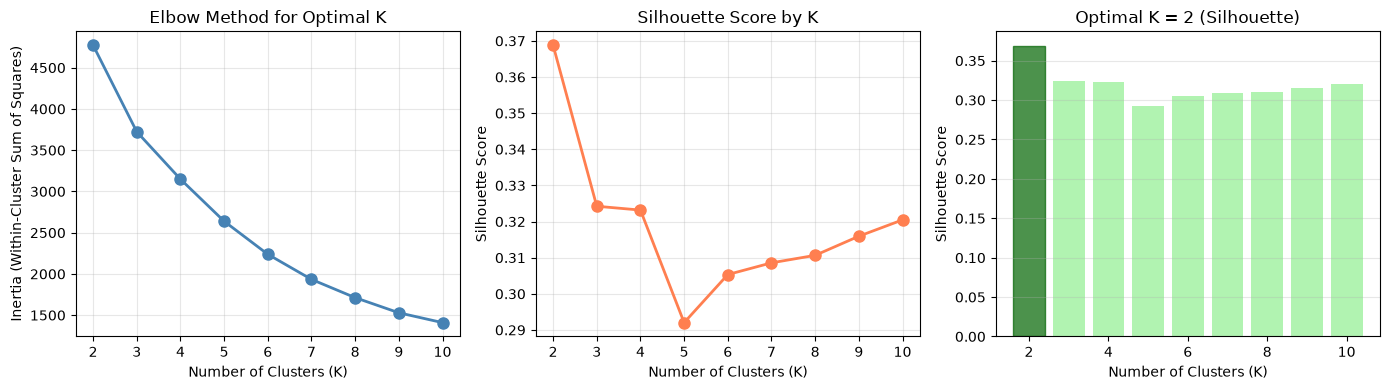


*** Optimal number of clusters: K = 2 ***
Best Silhouette Score: 0.3688


In [4]:
# Elbow Method: Test K from 2 to 10
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for K in K_range:
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))
    print(f'K={K}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={silhouette_scores[-1]:.4f}')

# Visualize Elbow Method and Silhouette Scores
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(K_range, inertias, 'o-', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(K_range, silhouette_scores, 'o-', linewidth=2, markersize=8, color='coral')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')
plt.grid(True, alpha=0.3)

# Find optimal K based on silhouette score
optimal_k = K_range[np.argmax(silhouette_scores)]
plt.subplot(1, 3, 3)
bars = plt.bar(K_range, silhouette_scores, alpha=0.7, color='lightgreen')
bars[optimal_k - 2].set_color('darkgreen')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title(f'Optimal K = {optimal_k} (Silhouette)')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'\n*** Optimal number of clusters: K = {optimal_k} ***')
print(f'Best Silhouette Score: {max(silhouette_scores):.4f}')

## 5. K-Means Clustering with Optimal K


In [5]:
# Fit K-Means with optimal K
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels

print(f'K-Means clustering with K={optimal_k} completed')
print(f'\nCluster distribution:')
print(df['Cluster'].value_counts().sort_index())
print(f'\nCluster proportions:')
print(df['Cluster'].value_counts(normalize=True).sort_index())

# Silhouette Analysis
silhouette_vals = silhouette_samples(X_pca, cluster_labels)
avg_silhouette = silhouette_score(X_pca, cluster_labels)

print(f'\nOverall Silhouette Score: {avg_silhouette:.4f}')
print('\nPer-Cluster Silhouette Scores:')
for i in range(optimal_k):
    cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    print(f'  Cluster {i}: Mean={cluster_silhouette_vals.mean():.4f}, Std={cluster_silhouette_vals.std():.4f}')

K-Means clustering with K=2 completed

Cluster distribution:
Cluster
0    600
1    600
Name: count, dtype: int64

Cluster proportions:
Cluster
0    0.5
1    0.5
Name: proportion, dtype: float64

Overall Silhouette Score: 0.3688

Per-Cluster Silhouette Scores:
  Cluster 0: Mean=0.3402, Std=0.1253
  Cluster 1: Mean=0.3974, Std=0.1288


## 6. PCA Visualization - 2D and 3D Scatter Plots


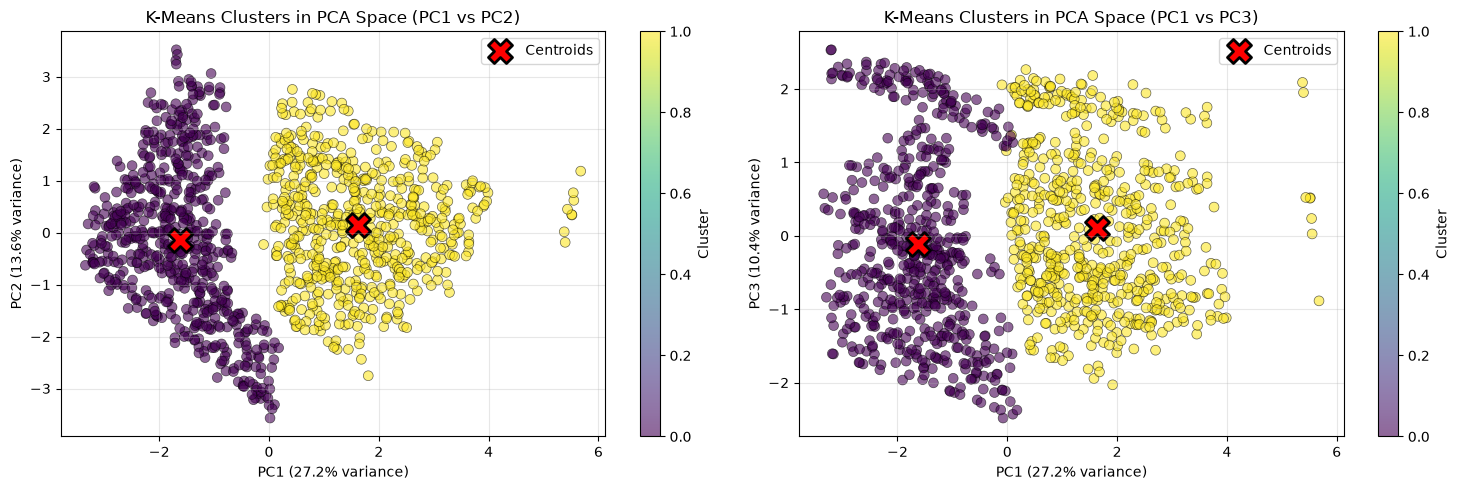

In [6]:
# 2D PCA scatter plot (PC1 vs PC2)
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', 
                       alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel(f'PC1 ({explained_var_ratio[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_var_ratio[1]*100:.1f}% variance)')
plt.title('K-Means Clusters in PCA Space (PC1 vs PC2)')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)

# 2D PCA scatter plot (PC1 vs PC3)
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 2], c=cluster_labels, cmap='viridis', 
                       alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 2],
            c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel(f'PC1 ({explained_var_ratio[0]*100:.1f}% variance)')
plt.ylabel(f'PC3 ({explained_var_ratio[2]*100:.1f}% variance)')
plt.title('K-Means Clusters in PCA Space (PC1 vs PC3)')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Cluster Profiling - Business Personas


In [7]:
# Analyze cluster characteristics using original features
cluster_profiles = df.groupby('Cluster')[feature_cols].mean()

print('\n' + '='*80)
print('CLUSTER PROFILES - MEAN VALUES BY CLUSTER')
print('='*80)
print(cluster_profiles.round(3))

# Summary statistics by cluster
print('\n' + '='*80)
print('CLUSTER SIZES AND KEY METRICS')
print('='*80)
for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    print(f'\nCluster {cluster_id}:')
    print(f'  Size: {len(cluster_data)} customers ({len(cluster_data)/len(df)*100:.1f}%)')
    print(f'  Avg Total Price: ${cluster_data["TotalPrice"].mean():.2f}')
    print(f'  Avg Quantity: {cluster_data["Quantity"].mean():.2f}')
    print(f'  Avg Cart Fill Ratio: {cluster_data["cart_fill_ratio"].mean():.3f}')
    print(f'  High Value Orders: {cluster_data["is_high_value_order"].mean()*100:.1f}%')
    print(f'  Discount Users: {cluster_data["discount_flag"].mean()*100:.1f}%')
    print(f'  Referral Users: {cluster_data["referral_feature"].mean()*100:.1f}%')


CLUSTER PROFILES - MEAN VALUES BY CLUSTER
         Quantity  UnitPrice  ItemsInCart  TotalPrice  order_year  \
Cluster                                                             
0           2.177    243.689        4.712     401.478    2023.778   
1           3.715    469.137        6.258    1705.809    2023.757   

         order_month  order_dayofweek  discount_flag  price_per_item  \
Cluster                                                                
0              6.158            3.078          0.745         243.689   
1              5.832            3.023          0.740         469.137   

         cart_fill_ratio  is_high_value_order  referral_feature  \
Cluster                                                           
0                  0.521                  0.0             0.782   
1                  0.639                  1.0             0.802   

         Quantity_is_outlier  UnitPrice_is_outlier  ItemsInCart_is_outlier  \
Cluster                                     

## 8. Persona Definition and Business Interpretation


In [8]:
# Define personas based on cluster analysis
personas = {}

for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    avg_price = cluster_data['TotalPrice'].mean()
    avg_quantity = cluster_data['Quantity'].mean()
    high_value_pct = cluster_data['is_high_value_order'].mean()
    discount_pct = cluster_data['discount_flag'].mean()
    referral_pct = cluster_data['referral_feature'].mean()
    
    # Create persona name and characteristics
    if avg_price > cluster_profiles['TotalPrice'].mean() and high_value_pct > 0.5:
        persona_name = 'Premium Spender'
        description = 'High-value customers with large order amounts and strong purchasing power'
    elif discount_pct > 0.7 and avg_price < cluster_profiles['TotalPrice'].mean():
        persona_name = 'Discount Hunter'
        description = 'Price-sensitive customers who actively seek and use discount codes'
    elif referral_pct > 0.6:
        persona_name = 'Referral Advocate'
        description = 'Customers who come from referral channels and engage with social platforms'
    elif avg_quantity > cluster_profiles['Quantity'].mean():
        persona_name = 'Bulk Buyer'
        description = 'Customers who consistently order in larger quantities per transaction'
    else:
        persona_name = 'Regular Customer'
        description = 'Average customers with typical purchasing patterns'
    
    personas[cluster_id] = {
        'name': persona_name,
        'description': description,
        'size': len(cluster_data),
        'pct': len(cluster_data) / len(df) * 100
    }

print('\n' + '='*80)
print('CUSTOMER PERSONAS')
print('='*80)
for cluster_id, persona in personas.items():
    print(f"\nCluster {cluster_id}: {persona['name']}")
    print(f"  Description: {persona['description']}")
    print(f"  Size: {persona['size']} customers ({persona['pct']:.1f}% of total)")
    print(f"  Recommended Strategy:")
    if 'Premium' in persona['name']:
        print(f"    - Focus on premium product recommendations and VIP services")
        print(f"    - Implement loyalty rewards program for high spenders")
    elif 'Discount' in persona['name']:
        print(f"    - Create targeted discount campaigns and promotional bundles")
        print(f"    - Use coupon codes to drive repeat purchases")
    elif 'Referral' in persona['name']:
        print(f"    - Amplify referral marketing and social media campaigns")
        print(f"    - Incentivize referrals with special rewards")
    elif 'Bulk' in persona['name']:
        print(f"    - Offer bulk purchase discounts and wholesale pricing")
        print(f"    - Suggest volume-based product bundles")
    else:
        print(f"    - Maintain consistent engagement with general offers")
        print(f"    - Cross-sell complementary products")


CUSTOMER PERSONAS

Cluster 0: Discount Hunter
  Description: Price-sensitive customers who actively seek and use discount codes
  Size: 600 customers (50.0% of total)
  Recommended Strategy:
    - Create targeted discount campaigns and promotional bundles
    - Use coupon codes to drive repeat purchases

Cluster 1: Premium Spender
  Description: High-value customers with large order amounts and strong purchasing power
  Size: 600 customers (50.0% of total)
  Recommended Strategy:
    - Focus on premium product recommendations and VIP services
    - Implement loyalty rewards program for high spenders


## 9. Heatmap Visualization - Cluster Characteristics


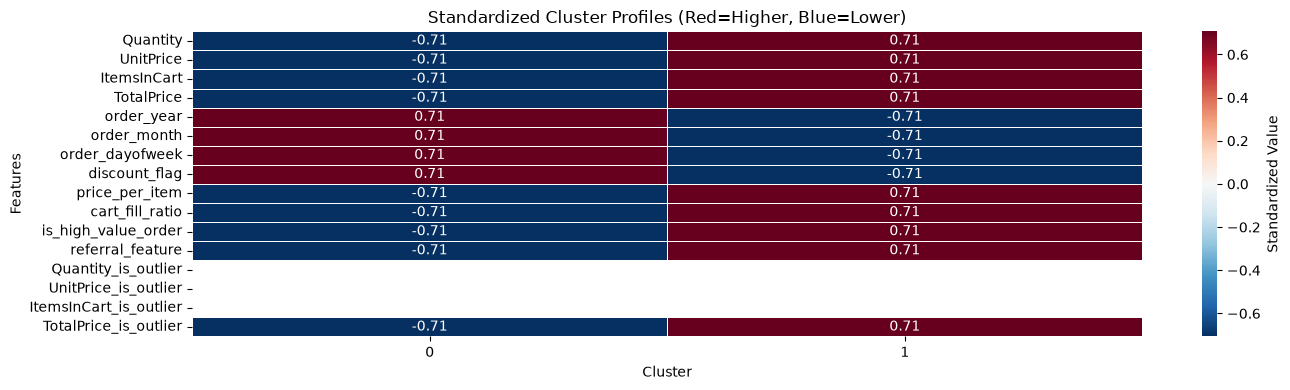

Heatmap shows standardized feature values per cluster
Red indicates above-average values, Blue indicates below-average values


In [9]:
# Standardize cluster profiles for heatmap visualization
cluster_profiles_scaled = (cluster_profiles - cluster_profiles.mean()) / cluster_profiles.std()

plt.figure(figsize=(14, 4))
sns.heatmap(cluster_profiles_scaled.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Standardized Value'}, linewidths=0.5)
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.title('Standardized Cluster Profiles (Red=Higher, Blue=Lower)')
plt.tight_layout()
plt.show()

print('Heatmap shows standardized feature values per cluster')
print('Red indicates above-average values, Blue indicates below-average values')

## 10. Summary and Business Recommendations


In [10]:
summary_report = f"""
{'='*80}
CUSTOMER SEGMENTATION - FINAL REPORT
{'='*80}

METHODOLOGY:
- Features: {len(feature_cols)} numeric attributes (standardized)
- Dimensionality Reduction: PCA to 3 components
  * PC1 explains {explained_var_ratio[0]*100:.1f}% of variance
  * PC2 explains {explained_var_ratio[1]*100:.1f}% of variance
  * PC3 explains {explained_var_ratio[2]*100:.1f}% of variance
  * Total: {cumulative_var_ratio[-1]*100:.1f}% variance retained

- Clustering Algorithm: K-Means
- Optimal K: {optimal_k} clusters (via Silhouette Score = {max(silhouette_scores):.4f})

CUSTOMER SEGMENTS:
"""

for cluster_id, persona in personas.items():
    summary_report += f"""
Segment {cluster_id}: {persona['name']}
  - Population: {persona['size']} customers ({persona['pct']:.1f}%)
  - {persona['description']}
"""

summary_report += f"""
{'='*80}
BUSINESS RECOMMENDATIONS:
{'='*80}
1. Use these customer personas for targeted marketing campaigns
2. Develop segment-specific products and pricing strategies
3. Personalize customer experiences based on segment characteristics
4. Allocate marketing budget proportionally to segment sizes and profitability
5. Monitor segment migration over time to track customer lifecycle
6. Re-run clustering quarterly to identify emerging segments
"""

print(summary_report)


CUSTOMER SEGMENTATION - FINAL REPORT

METHODOLOGY:
- Features: 16 numeric attributes (standardized)
- Dimensionality Reduction: PCA to 3 components
  * PC1 explains 27.2% of variance
  * PC2 explains 13.6% of variance
  * PC3 explains 10.4% of variance
  * Total: 51.3% variance retained

- Clustering Algorithm: K-Means
- Optimal K: 2 clusters (via Silhouette Score = 0.3688)

CUSTOMER SEGMENTS:

Segment 0: Discount Hunter
  - Population: 600 customers (50.0%)
  - Price-sensitive customers who actively seek and use discount codes

Segment 1: Premium Spender
  - Population: 600 customers (50.0%)
  - High-value customers with large order amounts and strong purchasing power

BUSINESS RECOMMENDATIONS:
1. Use these customer personas for targeted marketing campaigns
2. Develop segment-specific products and pricing strategies
3. Personalize customer experiences based on segment characteristics
4. Allocate marketing budget proportionally to segment sizes and profitability
5. Monitor segment mig